<a href="https://colab.research.google.com/github/MMujtabaX/word-embeddings-vs-tfidf/blob/main/word_embeddings_vs_tfidf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embeddings vs TF-IDF

Two ways to turn text into numbers: **sparse word counts weighted by rarity (TF-IDF)** and **dense vectors that encode meaning (word embeddings)**. This notebook explains both, explores pretrained **GloVe** vectors, trains **Word2Vec** (CBOW and Skip-gram) from scratch on 40,000 movie reviews, and then puts all of them head to head on a real task: **IMDB sentiment classification**.

### Difference Between Word Embedding and TF-IDF

**Word Embedding**:
- **Definition**: Word embeddings, such as Word2Vec, GloVe, or FastText, are dense vector representations of words that capture their semantic meaning. Each word is mapped to a fixed-size vector in a continuous vector space.
- **Key Features**:
  - Embeddings encode semantic relationships. For example, the vector difference between "king" and "queen" might be similar to the difference between "man" and "woman."
  - They are learned from large text corpora using models like Word2Vec (CBOW or Skip-Gram) or GloVe.
  - They are context-independent (traditional word embeddings). However, newer models like BERT provide context-dependent embeddings.
- **Example**: The vector for "cat" will be close to the vector for "dog" because they share similar contexts in the training data.

**TF-IDF (Term Frequency-Inverse Document Frequency)**:
- **Definition**: TF-IDF is a statistical measure that evaluates the importance of a word in a document relative to a collection of documents. It represents words as sparse vectors.
- **Key Features**:
  - Focuses on the frequency of words and their uniqueness across documents.
  - TF (term frequency) measures how often a word appears in a document.
  - IDF (inverse document frequency) measures how unique or rare a word is across all documents.
  - Words with high TF-IDF values are considered more important in the document.
- **Example**: In a corpus about "dogs," the word "dog" might have a high TF-IDF score in specific documents where it is particularly relevant.

---

| Aspect                  | Word Embedding                                  | TF-IDF                                      |
|-------------------------|------------------------------------------------|--------------------------------------------|
| **Representation**      | Dense, fixed-size vectors.                     | Sparse vectors (dimensionality = vocabulary size). |
| **Semantic Meaning**    | Captures semantic relationships between words. | Does not capture semantic meaning.         |
| **Context**             | Can encode some context (modern embeddings).   | Does not consider word order or context.   |
| **Use Case**            | Useful for semantic tasks (e.g., similarity, clustering). | Good for keyword extraction and document comparison. |
| **Learning Method**     | Trained on large text corpora using neural networks. | Calculated using term frequencies and corpus statistics. |
| **Dimensionality**      | Lower dimensionality, usually predefined (e.g., 100, 300). | Very high dimensionality, equal to the size of the vocabulary. |

---

**Use Case Scenarios**:
- **Word Embeddings**: Ideal for tasks requiring semantic understanding, like word similarity, analogies, and advanced NLP models (e.g., LSTMs or transformers).
- **TF-IDF**: Suitable for keyword extraction, information retrieval, and tasks where frequency-based importance is more relevant.


**CBOW (Continuous Bag of Words):**

- **Objective**: Predict a target word (center word) based on its surrounding context words (neighboring words).
- **Mechanism**:
  1. Given a context window (e.g., two words on each side), CBOW takes the context words as input.
  2. It averages (or sums) the vectors of the context words to create a single vector.
  3. This vector is passed through a neural network to predict the probability distribution of the target word.
  4. The word with the highest probability is chosen as the predicted word.
- **Key Feature**: CBOW is computationally efficient because it uses the aggregated context vector for prediction.
- **Example**: For the sentence "I love natural language processing," if "natural" is the target word and the window size is 2, CBOW uses ["I", "love", "language", "processing"] as input to predict "natural."

---

**Skip-Gram:**

- **Objective**: Predict the context words based on a given target word.
- **Mechanism**:
  1. Skip-gram takes one word (the center word) as input.
  2. It uses this word's vector to predict the probability distribution of the context words.
  3. Each context word is predicted individually, resulting in multiple predictions for one input word.
  4. Words with the highest probabilities are chosen as the predicted context words.
- **Key Feature**: Skip-gram performs well on smaller datasets and captures more detailed semantic relationships.
- **Example**: For the same sentence "I love natural language processing," if "natural" is the center word and the window size is 2, Skip-gram predicts ["I", "love", "language", "processing"] based on "natural."

---

**Key Differences Between CBOW and Skip-Gram**:

| Aspect            | CBOW                                 | Skip-Gram                          |
|-------------------|--------------------------------------|------------------------------------|
| **Prediction**    | Predicts the target word from context | Predicts context words from the target word |
| **Efficiency**    | Computationally efficient            | More computationally intensive      |
| **Dataset Size**  | Suitable for larger datasets         | Works well on smaller datasets      |
| **Detail**        | Captures overall semantic meaning    | Captures fine-grained relationships |
| **Training Speed**| Faster                              | Slower                              |

Both algorithms are part of the Word2Vec model and are widely used in NLP tasks for learning word embeddings.

In [1]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

---
## 1. Pretrained Embeddings: GloVe

**GloVe** vectors were trained on 6 billion tokens of Wikipedia and news text. We load the 50-dimensional version: 400,000 words, each a list of 50 numbers.

In [2]:
glove = api.load('glove-wiki-gigaword-50')
print(f"Vocabulary: {len(glove.key_to_index):,} words × {glove.vector_size} dimensions")
print("\nVector for 'movie' (first 10 of 50 values):")
print(np.round(glove['movie'][:10], 3))

Vocabulary: 400,000 words × 50 dimensions

Vector for 'movie' (first 10 of 50 values):
[ 0.308  0.172 -0.233  0.023  0.285  0.231 -0.41  -1.004 -0.207  1.433]


### Nearest neighbors
Words used in similar contexts end up close together in the vector space.

In [3]:
pd.DataFrame({w: [f"{n} ({s:.2f})" for n, s in glove.most_similar(w, topn=6)]
              for w in ['excellent', 'awful', 'computer', 'karachi', 'cricket']})

,excellent,awful,computer,karachi,cricket
0,quality (0.86),horrible (0.93),computers (0.92),lahore (0.89),indies (0.81)
1,good (0.81),terrible (0.89),software (0.88),peshawar (0.88),twenty20 (0.81)
2,skill (0.79),dreadful (0.87),technology (0.85),mumbai (0.85),rugby (0.80)
3,skills (0.77),unbelievable (0.85),electronic (0.81),dhaka (0.82),cricketers (0.80)
4,superb (0.77),scary (0.83),internet (0.81),quetta (0.80),england (0.78)
5,best (0.77),weird (0.82),computing (0.80),bombay (0.80),wc2003 (0.75)


### Analogies: vector arithmetic on meaning
`king − man + woman ≈ ?` The *direction* from "man" to "king" encodes something like royalty, and adding it to "woman" lands near "queen".

In [4]:
analogies = [
    ('king', 'man', 'woman'),
    ('paris', 'france', 'italy'),
    ('walking', 'walk', 'swim'),
    ('bigger', 'big', 'small'),
    ('pakistan', 'islamabad', 'tokyo'),
]
rows = []
for a, b, c in analogies:
    answer, score = glove.most_similar(positive=[a, c], negative=[b], topn=1)[0]
    rows.append({'analogy': f"{a} − {b} + {c}", 'answer': answer, 'similarity': round(score, 3)})
pd.DataFrame(rows)

,analogy,answer,similarity
0,king − man + woman,queen,0.852
1,paris − france + italy,rome,0.847
2,walking − walk + swim,swimming,0.807
3,bigger − big + small,larger,0.924
4,pakistan − islamabad + tokyo,japan,0.914


In [5]:
for group in [['breakfast', 'lunch', 'dinner', 'car'],
              ['python', 'java', 'javascript', 'banana'],
              ['happy', 'joyful', 'cheerful', 'angry']]:
    print(f"Odd one out in {group}: {glove.doesnt_match(group)}")

Odd one out in ['breakfast', 'lunch', 'dinner', 'car']: car
Odd one out in ['python', 'java', 'javascript', 'banana']: banana
Odd one out in ['happy', 'joyful', 'cheerful', 'angry']: angry


### Visualizing the embedding space
PCA projects 50 dimensions to 2. Words from the same category form clusters, and the country → capital offsets point in a similar direction.

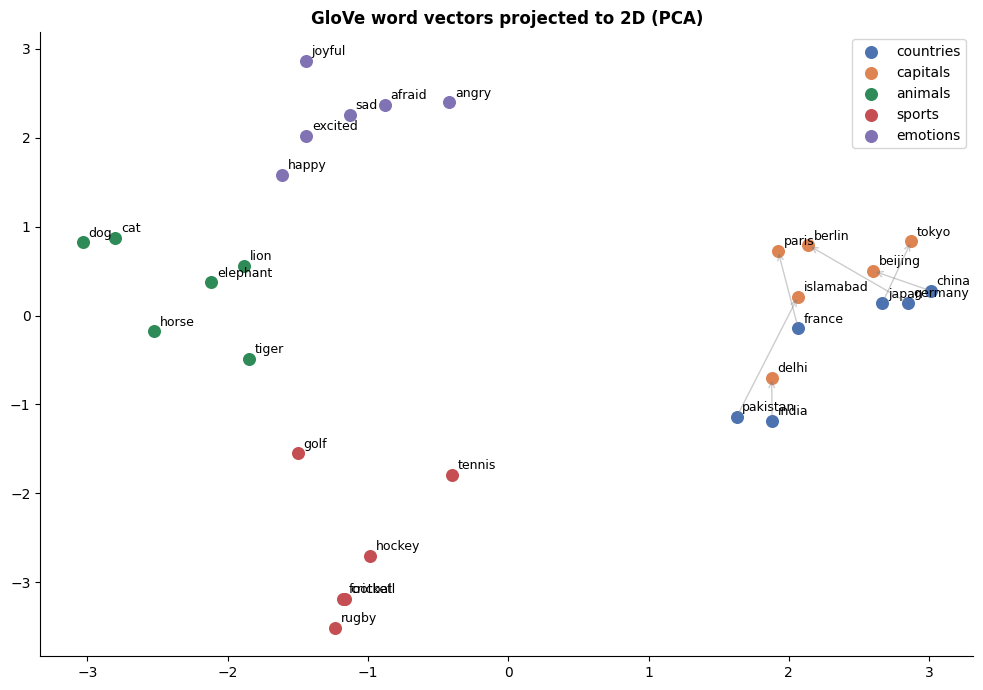

In [6]:
groups = {
    'countries': ['pakistan', 'india', 'china', 'france', 'germany', 'japan'],
    'capitals':  ['islamabad', 'delhi', 'beijing', 'paris', 'berlin', 'tokyo'],
    'animals':   ['dog', 'cat', 'horse', 'lion', 'tiger', 'elephant'],
    'sports':    ['cricket', 'football', 'tennis', 'hockey', 'golf', 'rugby'],
    'emotions':  ['happy', 'sad', 'angry', 'afraid', 'joyful', 'excited'],
}
words = [w for ws in groups.values() for w in ws]
coords = PCA(n_components=2, random_state=42).fit_transform(np.array([glove[w] for w in words]))
xy = dict(zip(words, coords))

plt.figure(figsize=(10, 7))
colors = ['#4C72B0', '#DD8452', '#2E8B57', '#C44E52', '#8172B3']
for (name, ws), c in zip(groups.items(), colors):
    pts = np.array([xy[w] for w in ws])
    plt.scatter(pts[:, 0], pts[:, 1], s=70, color=c, label=name)
    for w in ws:
        plt.annotate(w, xy[w], xytext=(4, 4), textcoords='offset points', fontsize=9)
for country, capital in zip(groups['countries'], groups['capitals']):
    plt.annotate('', xy=xy[capital], xytext=xy[country],
                 arrowprops=dict(arrowstyle='->', color='grey', alpha=0.4))
plt.title('GloVe word vectors projected to 2D (PCA)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 2. Sentence Similarity: Where TF-IDF Falls Short and Where Embeddings Do

A simple way to embed a sentence is to **average its word vectors**. Let's compare how TF-IDF and averaged GloVe vectors judge sentence similarity.

In [7]:
def glove_sentence(text):
    vecs = [glove[w] for w in tokenize(text) if w in glove.key_to_index]
    return np.mean(vecs, axis=0) if vecs else np.zeros(glove.vector_size)

pairs = [
    ("The movie was fantastic",      "The film was great",           "paraphrase"),
    ("I loved this picture",         "I adored this film",           "paraphrase"),
    ("The acting was superb",        "The performances were excellent", "paraphrase"),
    ("The movie was fantastic",      "The weather is cold today",    "unrelated"),
    ("The movie was fantastic",      "The movie was terrible",       "opposite meaning"),
]

all_sentences = [s for a, b, _ in pairs for s in (a, b)]
tfidf_sent = TfidfVectorizer().fit(all_sentences)

rows = []
for a, b, kind in pairs:
    t = cosine_similarity(tfidf_sent.transform([a]), tfidf_sent.transform([b]))[0, 0]
    g = cosine_similarity([glove_sentence(a)], [glove_sentence(b)])[0, 0]
    rows.append({'sentence A': a, 'sentence B': b, 'relation': kind,
                 'TF-IDF cosine': round(t, 2), 'GloVe cosine': round(g, 2)})
similarity = pd.DataFrame(rows)
similarity

,sentence A,sentence B,relation,TF-IDF cosine,GloVe cosine
0,The movie was fantastic,The film was great,paraphrase,0.27,0.97
1,I loved this picture,I adored this film,paraphrase,0.28,0.95
2,The acting was superb,The performances were excellent,paraphrase,0.07,0.88
3,The movie was fantastic,The weather is cold today,unrelated,0.08,0.80
4,The movie was fantastic,The movie was terrible,opposite meaning,0.55,0.97


**Three lessons from one table:**
- **Paraphrases:** TF-IDF only sees *shared words*. *"The acting was superb"* and *"The performances were excellent"* share only *"the"*, so TF-IDF scores them 0.07. GloVe scores them 0.88, because *superb ≈ excellent* and *acting ≈ performances*.
- **Opposites:** GloVe rates *"The movie was fantastic"* vs *"The movie was terrible"* at **0.97**, as high as a true paraphrase. Antonyms appear in the **same contexts** ("the movie was ___"), so distributional embeddings place them close together. Embeddings capture *relatedness*, not *agreement*, which matters a lot for sentiment.
- **Averaged vectors are compressed:** even the unrelated weather sentence scores 0.80 with GloVe, because averaging pulls every sentence toward a common "average English" direction. Rankings matter more than absolute values.

---
## 3. Training Our Own Word2Vec: CBOW vs Skip-gram

Pretrained vectors reflect Wikipedia and news. Training on **movie reviews** gives vectors that understand film vocabulary and opinion words. We load 50,000 IMDB reviews and train Word2Vec on the 40,000 training reviews (labels aren't used, since Word2Vec is unsupervised).

In [8]:
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
imdb = pd.read_csv(url)
imdb['review'] = imdb['review'].str.replace(r'<br\s*/?>', ' ', regex=True)
imdb['label'] = (imdb['sentiment'] == 'positive').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    imdb['review'], imdb['label'], test_size=0.2, random_state=42, stratify=imdb['label'])

train_tokens = [tokenize(t) for t in X_train]
test_tokens = [tokenize(t) for t in X_test]
print(f"Training reviews: {len(train_tokens):,}   Words: {sum(map(len, train_tokens)):,}")

Training reviews: 40,000   Words: 9,197,475


In [9]:
w2v = {}
for name, sg in [('CBOW', 0), ('Skip-gram', 1)]:
    start = time.time()
    w2v[name] = Word2Vec(train_tokens, vector_size=100, window=5, min_count=5,
                         sg=sg, workers=4, epochs=5, seed=42)
    print(f"{name:<9} trained in {time.time() - start:5.1f}s   vocabulary: {len(w2v[name].wv):,}")

CBOW      trained in  47.0s   vocabulary: 37,282


Skip-gram trained in 168.2s   vocabulary: 37,282


In [10]:
rows = []
for w in ['awful', 'brilliant', 'plot', 'actor', 'boring']:
    rows.append({
        'word': w,
        'GloVe (Wikipedia/news)': ", ".join(x for x, _ in glove.most_similar(w, topn=5)),
        'CBOW (IMDB)':            ", ".join(x for x, _ in w2v['CBOW'].wv.most_similar(w, topn=5)),
        'Skip-gram (IMDB)':       ", ".join(x for x, _ in w2v['Skip-gram'].wv.most_similar(w, topn=5)),
    })
pd.DataFrame(rows).set_index('word')

,GloVe (Wikipedia/news),CBOW (IMDB),Skip-gram (IMDB)
word,,,
awful,"horrible, terrible, dreadful, unbelievable, scary","terrible, horrible, dreadful, atrocious, ridic...","terrible, horrible, dreadful, abysmal, atrocious"
brilliant,"superb, terrific, brilliantly, excellent, amazing","fantastic, superb, terrific, wonderful, splendid","fantastic, wonderful, superb, splendid, great"
plot,"plots, plotting, plotted, conspiracy, secret","storyline, story, premise, script, narrative","storyline, plotline, plot's, story, plots"
actor,"starring, starred, actress, comedian, filmmaker","actress, comedian, performer, role, performance","actress, performer, impersonating, brosnan, ra..."
boring,"awfully, pretty, funny, incredibly, silly","dull, pointless, tedious, predictable, lame","dull, pointless, uneventful, tedious, predictable"


The IMDB-trained models learn **film-review semantics**. For *plot*, GloVe returns *plots, plotting, conspiracy* (the "secret plan" sense from news text), while the IMDB models return *storyline, premise, script, narrative*. For *boring*, GloVe gives *awfully, pretty, funny*; the IMDB models give *dull, pointless, tedious, predictable*, exactly how reviewers use the word.

**Skip-gram** makes a separate prediction for every context word, so it trained about **3.5× slower** than CBOW (168s vs 47s) but tends to give sharper vectors for rarer words.

---
## 4. The Showdown: Sentiment Classification

Same task, same train/test split (40,000 / 10,000 reviews), same classifier (logistic regression). Only the text representation changes:

| Representation | Dimensions | How a review becomes a vector |
|----------------|-----------|-------------------------------|
| **TF-IDF** (words + bigrams) | ~624,000, sparse | Weighted counts of every word and word pair |
| **GloVe average** | 50, dense | Mean of pretrained word vectors |
| **Word2Vec CBOW average** | 100, dense | Mean of IMDB-trained vectors |
| **Word2Vec Skip-gram average** | 100, dense | Mean of IMDB-trained vectors |

In [11]:
def average_vectors(token_lists, kv):
    dim = kv.vector_size
    out = np.zeros((len(token_lists), dim), dtype=np.float32)
    for i, toks in enumerate(token_lists):
        vecs = [kv[w] for w in toks if w in kv.key_to_index]
        if vecs:
            out[i] = np.mean(vecs, axis=0)
    return out

features = {}
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1, 2), sublinear_tf=True)
features['TF-IDF'] = (tfidf.fit_transform(X_train), tfidf.transform(X_test))
features['GloVe avg (50d)'] = (average_vectors(train_tokens, glove), average_vectors(test_tokens, glove))
for name in ['CBOW', 'Skip-gram']:
    kv = w2v[name].wv
    features[f'Word2Vec {name} avg (100d)'] = (average_vectors(train_tokens, kv), average_vectors(test_tokens, kv))

results = {}
for name, (Xtr, Xte) in features.items():
    clf = LogisticRegression(max_iter=3000, C=4 if name == 'TF-IDF' else 1.0).fit(Xtr, y_train)
    results[name] = accuracy_score(y_test, clf.predict(Xte))
    print(f"{name:<28} dims={Xtr.shape[1]:>7,}   accuracy={results[name]:.4f}")

TF-IDF                       dims=624,165   accuracy=0.9135
GloVe avg (50d)              dims=     50   accuracy=0.7552


Word2Vec CBOW avg (100d)     dims=    100   accuracy=0.8460
Word2Vec Skip-gram avg (100d) dims=    100   accuracy=0.8657


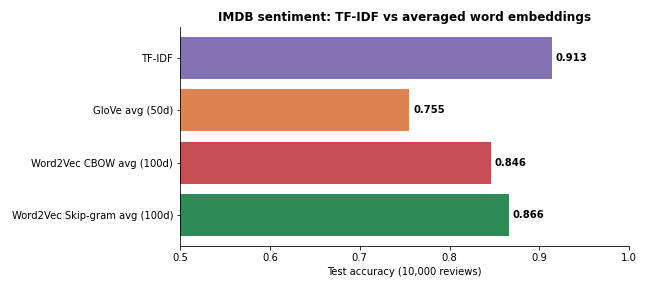

In [12]:
names = list(results)
plt.figure(figsize=(9, 4))
bars = plt.barh(names[::-1], [results[n] for n in names[::-1]],
                color=['#2E8B57', '#C44E52', '#DD8452', '#8172B3'])
plt.bar_label(bars, fmt='%.3f', padding=4, fontweight='bold')
plt.xlim(0.5, 1.0)
plt.xlabel('Test accuracy (10,000 reviews)')
plt.title('IMDB sentiment: TF-IDF vs averaged word embeddings', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Does the winner change with less labelled data?

A common claim is that embeddings help most when labelled data is scarce, because they bring knowledge learned elsewhere. We retrain each classifier on 100 to 40,000 labelled reviews (averaging 5 random samples for small sizes) and test on the same 10,000 reviews.

In [13]:
rng = np.random.RandomState(0)
sizes = [100, 300, 1000, 3000, 10000, 40000]
curve = {k: [] for k in ['TF-IDF', 'GloVe avg (50d)', 'Word2Vec CBOW avg (100d)']}
G_tr, G_te = features['GloVe avg (50d)']
C_tr, C_te = features['Word2Vec CBOW avg (100d)']

for n in sizes:
    reps = 5 if n <= 3000 else 1
    scores = {k: [] for k in curve}
    for _ in range(reps):
        idx = rng.choice(len(X_train), n, replace=False) if n < len(X_train) else np.arange(len(X_train))
        y = y_train.iloc[idx]
        vec = TfidfVectorizer(min_df=1 if n < 1000 else 2, sublinear_tf=True,
                              ngram_range=(1, 2) if n >= 10000 else (1, 1))
        A = vec.fit_transform(X_train.iloc[idx])
        scores['TF-IDF'].append(accuracy_score(y_test, LogisticRegression(max_iter=3000, C=4).fit(A, y).predict(vec.transform(X_test))))
        scores['GloVe avg (50d)'].append(accuracy_score(y_test, LogisticRegression(max_iter=3000).fit(G_tr[idx], y).predict(G_te)))
        scores['Word2Vec CBOW avg (100d)'].append(accuracy_score(y_test, LogisticRegression(max_iter=3000).fit(C_tr[idx], y).predict(C_te)))
    for k in curve:
        curve[k].append(np.mean(scores[k]))

learning = pd.DataFrame(curve, index=pd.Index(sizes, name='labelled reviews'))
learning.round(3)

,TF-IDF,GloVe avg (50d),Word2Vec CBOW avg (100d)
labelled reviews,,,
100,0.692,0.654,0.770
300,0.787,0.709,0.808
1000,0.837,0.733,0.828
3000,0.869,0.747,0.839
10000,0.897,0.754,0.845
40000,0.914,0.755,0.846


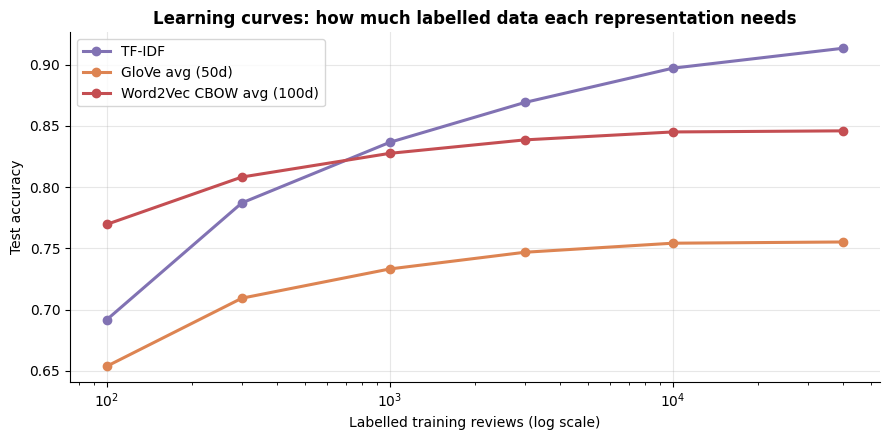

In [14]:
plt.figure(figsize=(9, 4.5))
for (name, color) in zip(curve, ['#8172B3', '#DD8452', '#C44E52']):
    plt.plot(sizes, learning[name], 'o-', lw=2.2, color=color, label=name)
plt.xscale('log')
plt.xlabel('Labelled training reviews (log scale)')
plt.ylabel('Test accuracy')
plt.title('Learning curves: how much labelled data each representation needs', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**What the experiments show:**
- **With plenty of labels, TF-IDF wins** (91.4% vs 86.6% for the best embedding). Sentiment is carried by specific words and phrases (*"waste of time"*, *"not worth"*, *"highly recommend"*), which sparse features keep separate. Averaging hundreds of word vectors blurs them into one point.
- **With very few labels, domain-trained embeddings win.** With only 100 labelled reviews, IMDB Word2Vec reaches **77.0%** vs TF-IDF's **69.2%**, and it still leads at 300. The embeddings were learned from 40,000 *unlabelled* reviews, so they bring knowledge that TF-IDF can't get from 100 examples. The lines cross at around 1,000 labelled reviews.
- **Domain matters enormously.** IMDB-trained Word2Vec beats general-purpose GloVe by about 10 points at every size. GloVe never catches up, partly because it's only 50-dimensional and partly because its notion of "boring" or "plot" isn't a reviewer's.
- **Where embeddings shine most:** word similarity, analogies, paraphrase detection, low-label settings, and as the **input layer of neural networks** (RNNs, CNNs, transformers) that combine word vectors in order instead of averaging them.

---
## Summary

| | TF-IDF | Static word embeddings (GloVe, Word2Vec) |
|--|--------|-------------------------------------------|
| Vector type | Sparse, ~vocabulary-sized | Dense, 50–300 dimensions |
| Captures synonyms | ❌ "film" ≠ "movie" | ✅ "film" ≈ "movie" |
| Distinguishes antonyms | ✅ different words | ⚠️ "great" ≈ "terrible" (similar contexts) |
| Classification, many labels | ✅ Strong baseline (91% on IMDB) | Weaker when averaged (75–87%) |
| Classification, ~100 labels | Weaker (69%) | ✅ Domain-trained Word2Vec wins (77%) |
| Word similarity / analogies | ❌ | ✅ |
| Training needed | None | Pretrained, or train on your own corpus |
| Best used for | Search, keyword features, strong linear baselines | Semantic similarity, feeding neural models |

Static embeddings give each word **one vector regardless of context** ("bank" is the same in "river bank" and "bank account"). **Contextual embeddings** from transformers like BERT solve that, which is the next step in modern NLP.